<a href="https://colab.research.google.com/github/banjworst/CSC_398_SIRP_Project/blob/main/CSC398_SIPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sports Injury Risk Prediction Project
**Objective:** Determine whether we can accurately predict an athlete's risk of injury using machine learning models.

## Steps for Usage

1. **Get the dataset:** Download SIRP-600 from Kaggle and upload to Colab using Cell 2
2. **Run Cells 4-5** to prepare data and split for training
3. **Train models** in section 6
4. **Evaluate** in section 7
5. **Visualize results** in sections 9-10
6. **Fine-tune** with GridSearchCV if needed (section 8)


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data from Kaggle

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('SIRP-600.xlsx')
print(df.head())

Saving SIRP-600.xlsx to SIRP-600.xlsx
   Age  Gender  Height_cm  Weight_kg    BMI  Training_Frequency  \
0   36       0      155.4       56.3  23.34                   1   
1   30       0      167.6       45.3  16.12                   4   
2   21       1      176.7       60.8  19.48                   1   
3   37       0      170.2       60.7  20.97                   5   
4   30       0      161.5       45.0  17.25                   6   

   Training_Duration  Warmup_Time  Sleep_Hours  Flexibility_Score  \
0                 94           20          7.2               63.3   
1                114            5          7.1               64.6   
2                 95           11          5.0               68.6   
3                 73            6          8.1               69.0   
4                 93            8          7.8               45.2   

   Muscle_Asymmetry  Recovery_Time  Injury_History  Stress_Level  \
0               3.7             63               1             8   
1       

## 3. Data Exploration

In [ ]:
# Display basic info about the dataset

print(df.columns.tolist())
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names and types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Training_Frequency', 'Training_Duration', 'Warmup_Time', 'Sleep_Hours', 'Flexibility_Score', 'Muscle_Asymmetry', 'Recovery_Time', 'Injury_History', 'Stress_Level', 'Training_Intensity', 'Injury_Risk']
   Age  Gender  Height_cm  Weight_kg    BMI  Training_Frequency  \
0   36       0      155.4       56.3  23.34                   1   
1   30       0      167.6       45.3  16.12                   4   
2   21       1      176.7       60.8  19.48                   1   
3   37       0      170.2       60.7  20.97                   5   
4   30       0      161.5       45.0  17.25                   6   

   Training_Duration  Warmup_Time  Sleep_Hours  Flexibility_Score  \
0                 94           20          7.2               63.3   
1                114            5          7.1               64.6   
2                 95           11          5.0               68.6   
3                 73            6          8.1               69.0   

## 4. Data Preparation

**Separate features (X) and target (y)**

In [ ]:
# Identify target column
TARGET_COLUMN = 'Injury_Risk'

X = df.drop(columns=[TARGET_COLUMN])  # Features
y = df[TARGET_COLUMN]  # Target

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features shape: (600, 15)
Target shape: (600,)

Target distribution:
Injury_Risk
0    411
1    189
Name: count, dtype: int64


## 5. Train-Test Split (80-20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=42, stratify=y
 )


print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (480, 15)
Testing set size: (120, 15)


## 6. Model Training

### 6.1 Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest trained!")

Random Forest trained!


### 6.2 Gradient Boosting

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting trained!")

Gradient Boosting trained!


### 6.3 Support Vector Classifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svc_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42, probability=True))
])

svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)
print("Support Vector Classifier trained!")

Support Vector Classifier trained!


## 7. Model Evaluation

**Metrics:** Accuracy, Precision, Recall, ROC-AUC

In [ ]:
def evaluate_model(model_name, y_test, y_pred, y_pred_proba=None):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    print(f"\n{model_name} Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")

    return accuracy, precision, recall

# Evaluate all models
rf_acc, rf_prec, rf_rec = evaluate_model('Random Forest', y_test, rf_pred)
gb_acc, gb_prec, gb_rec = evaluate_model('Gradient Boosting', y_test, gb_pred)
svc_acc, svc_prec, svc_rec = evaluate_model('SVC', y_test, svc_pred)


Random Forest Performance:
  Accuracy:  0.5417
  Precision: 0.2069
  Recall:    0.1579

Gradient Boosting Performance:
  Accuracy:  0.5417
  Precision: 0.2069
  Recall:    0.1579

SVC Performance:
  Accuracy:  0.8667
  Precision: 0.9231
  Recall:    0.6316


## 8. Hyperparameter Tuning (Optional - GridSearchCV)

**fill this in once we see which model performs best**

In [ ]:
# 8. Hyperparameter Tuning — GridSearchCV

# Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='recall', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_pred_tuned = rf_best.predict(X_test)
print(f"RF best params: {rf_grid.best_params_}")

# Gradient Boosting
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='recall', n_jobs=-1)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_
gb_pred_tuned = gb_best.predict(X_test)
print(f"GB best params: {gb_grid.best_params_}")

# SVC (tuning the inner svc step via Pipeline param naming)
svc_params = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto'],
    'svc__kernel': ['rbf', 'linear']
}
svc_grid = GridSearchCV(svc_model, svc_params, cv=5, scoring='recall', n_jobs=-1)
svc_grid.fit(X_train, y_train)
svc_best = svc_grid.best_estimator_
svc_pred_tuned = svc_best.predict(X_test)
print(f"SVC best params: {svc_grid.best_params_}")

# Evaluate tuned models
print("\n--- Tuned Model Performance ---")
rf_acc_t, rf_prec_t, rf_rec_t = evaluate_model('Random Forest (tuned)', y_test, rf_pred_tuned)
gb_acc_t, gb_prec_t, gb_rec_t = evaluate_model('Gradient Boosting (tuned)', y_test, gb_pred_tuned)
svc_acc_t, svc_prec_t, svc_rec_t = evaluate_model('SVC (tuned)', y_test, svc_pred_tuned)

RF best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
GB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
SVC best params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

--- Tuned Model Performance ---

Random Forest (tuned) Performance:
  Accuracy:  0.9583
  Precision: 1.0000
  Recall:    0.8684

Gradient Boosting (tuned) Performance:
  Accuracy:  0.9583
  Precision: 1.0000
  Recall:    0.8684

SVC (tuned) Performance:
  Accuracy:  0.8083
  Precision: 0.7027
  Recall:    0.6842


## 9. Visualizations

**Use this to create charts here once models are trained**

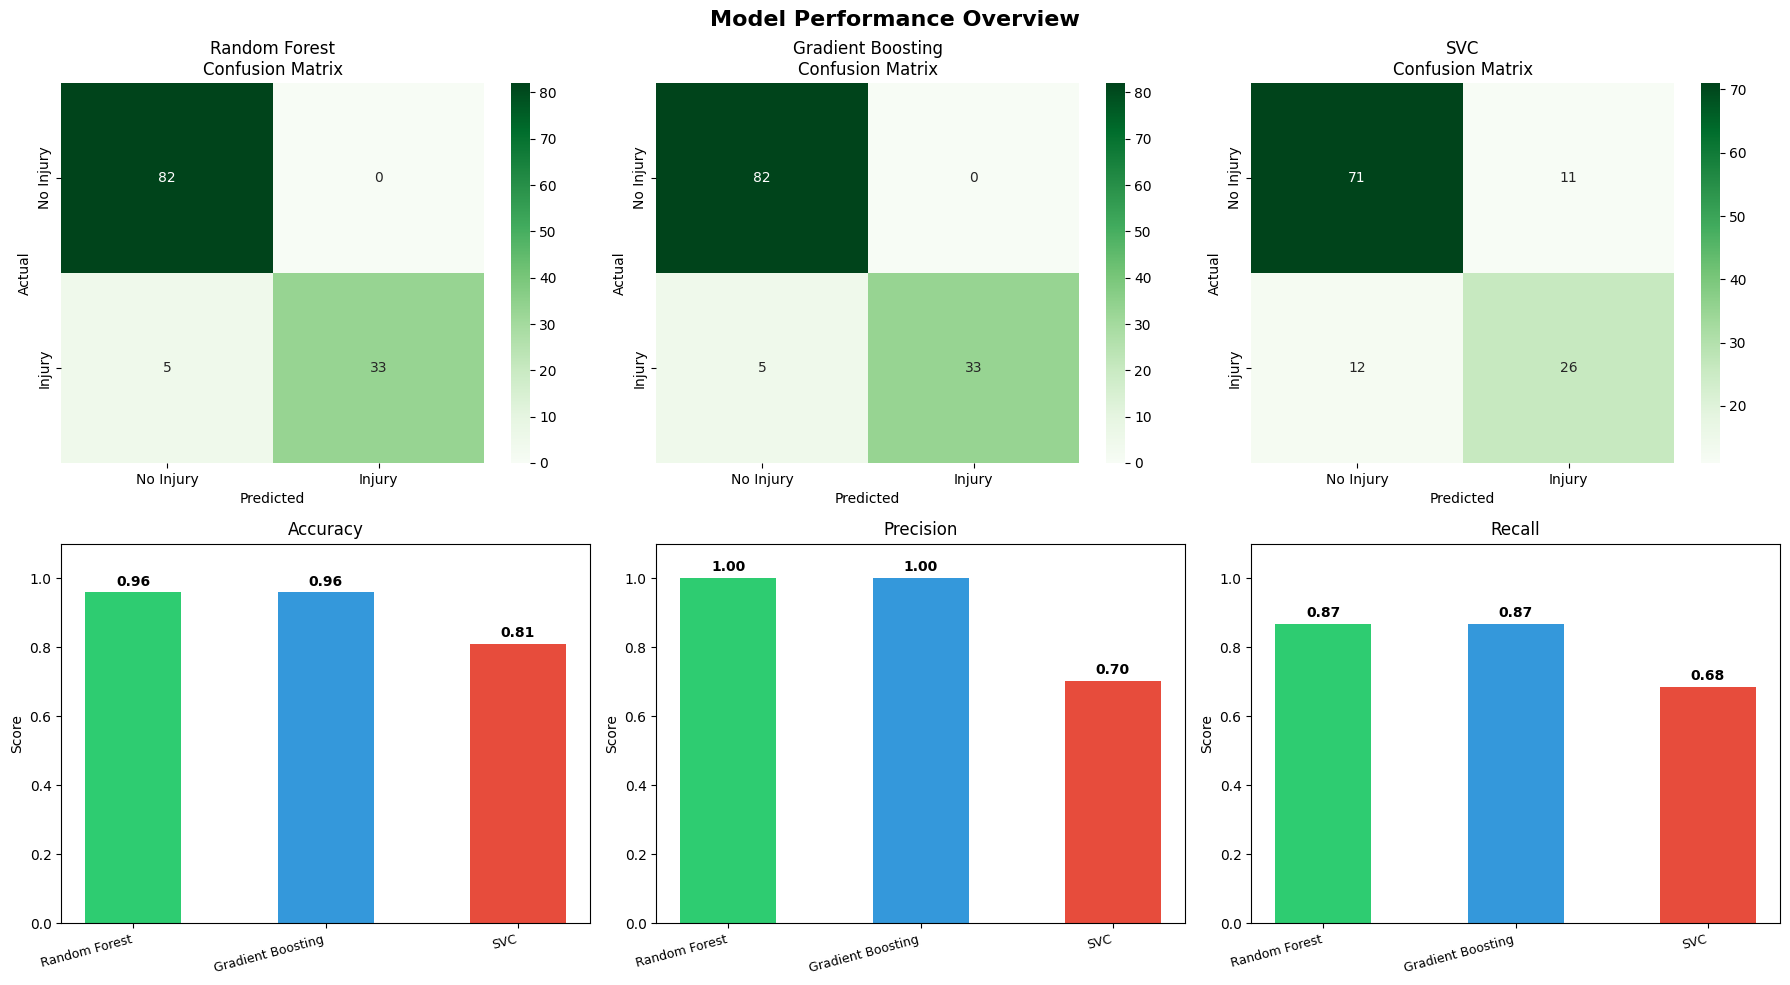

Visualization saved as model_performance.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Overview', fontsize=16, fontweight='bold')

# --- Row 1: Confusion Matrices ---
models_info = [
    ('Random Forest', y_test, rf_pred_tuned),
    ('Gradient Boosting', y_test, gb_pred_tuned),
    ('SVC', y_test, svc_pred_tuned)
]

for i, (name, y_true, y_pred) in enumerate(models_info):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0, i],
                xticklabels=['No Injury', 'Injury'],
                yticklabels=['No Injury', 'Injury'])
    axes[0, i].set_title(f'{name}\nConfusion Matrix', fontsize=12)
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')

# --- Row 2: Side-by-side metric comparison bar chart ---
model_names = ['Random Forest', 'Gradient Boosting', 'SVC']
accuracies  = [rf_acc_t,  gb_acc_t,  svc_acc_t]
precisions  = [rf_prec_t, gb_prec_t, svc_prec_t]
recalls     = [rf_rec_t,  gb_rec_t,  svc_rec_t]

x = np.arange(len(model_names))
width = 0.25
colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, (metric, values, label) in enumerate(zip(
    [accuracies, precisions, recalls],
    [accuracies, precisions, recalls],
    ['Accuracy', 'Precision', 'Recall']
)):
    axes[1, idx].bar(x, values, color=colors, width=0.5)
    axes[1, idx].set_title(label, fontsize=12)
    axes[1, idx].set_xticks(x)
    axes[1, idx].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    axes[1, idx].set_ylim(0, 1.1)
    axes[1, idx].set_ylabel('Score')
    for j, v in enumerate(values):
        axes[1, idx].text(j, v + 0.02, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as model_performance.png")

## 10. ROC Curves

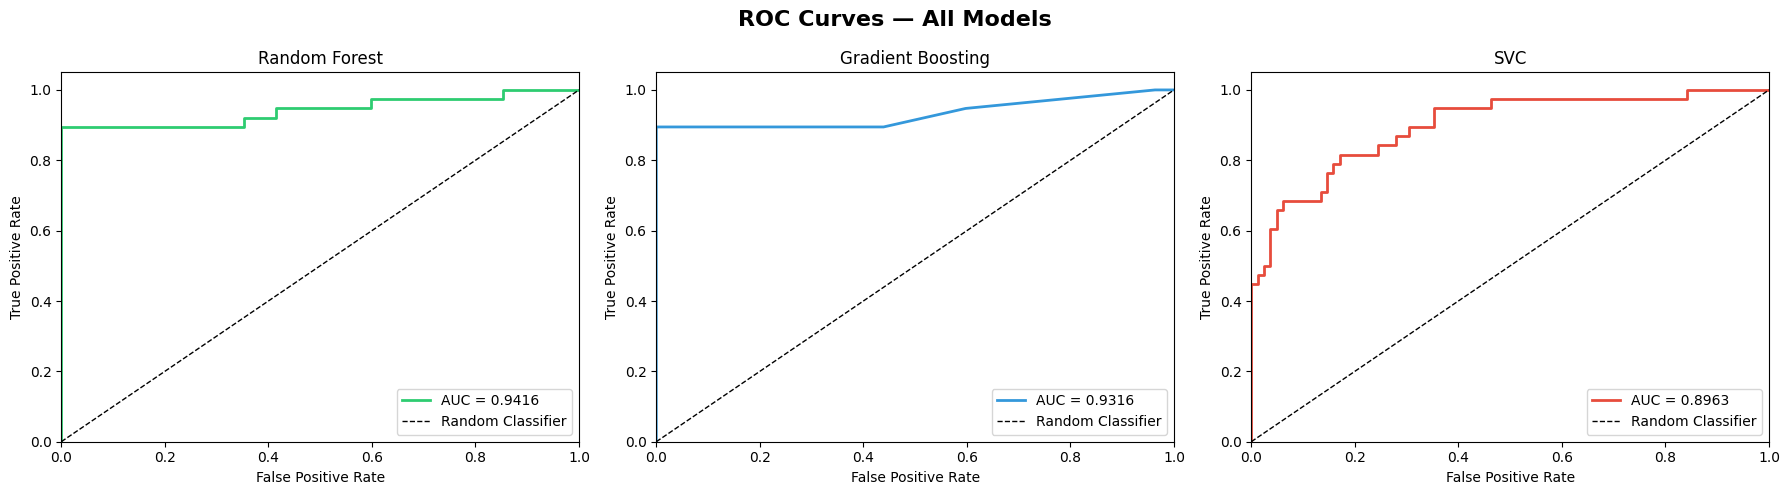

ROC curves saved as roc_curves.png


In [ ]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves — All Models', fontsize=16, fontweight='bold')

tuned_models = [
    ('Random Forest', rf_best),
    ('Gradient Boosting', gb_best),
    ('SVC', svc_best)
]

colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, (name, model) in enumerate(tuned_models):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'AUC = {roc_auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    axes[i].set_title(f'{name}', fontsize=12)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved as roc_curves.png")